# Targeted Attack + Low-Rank Vaccination by Score Tier

attack points that belong to structure (low noise score)
or noise (high noise score), then apply k-rank SVD vaccination and measure
restoration rate and post-vaccination ASR.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import json
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# DATA_DIR = Path('spambase_50_50')
DATA_DIR = Path('spambase_10_40_50')
SCORES_DIR = Path('noise_scoring_outputs/20260324_203954')
# OUTPUT_DIR = Path('targeted_vaccination_results')
OUTPUT_DIR = Path('targeted_vaccination_results_10_40_50')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.1
MAXITERS = 300
LAMBDAS = {'aggressive': 0.1, 'stealthy': 50.0}
ATTACK_PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
K_RANKS = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]

Device: cuda
GPU: NVIDIA RTX A6000


## 1. Load Data, Model, and Noise Scores

In [2]:
data = np.load(DATA_DIR / 'train_test_data.npz')
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test']
n_test, n_features = X_test.shape

prep = np.load(DATA_DIR / 'preprocessing.npz')
weights = prep['weights']
bounds = [prep['bounds_min'], prep['bounds_max']]


class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)


checkpoint = torch.load(DATA_DIR / 'spambase_mlp.pth', map_location=device)
model = SpambaseNet(checkpoint['D_in']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

X_test_t = torch.FloatTensor(X_test).to(device)
with torch.no_grad():
    test_preds = model(X_test_t).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)

print(f'Test set: {n_test} samples, {n_features} features')
print(f'Correctly classified: {n_correct}/{n_test} ({n_correct/n_test:.2%})')

Test set: 2301 samples, 57 features
Correctly classified: 2058/2301 (89.44%)


In [3]:
score1_removal_order = np.load(SCORES_DIR / 'test_clean_data_score1_removed_index.npy').astype(int)
score2_value = np.load(SCORES_DIR / 'test_clean_data_score2_noise_scores.npy')

# Noisiest-first orderings, filtered to correctly-classified only
score1_order = [idx for idx in score1_removal_order if correct_mask[idx]]
score2_order = [idx for idx in np.argsort(score2_value)[::-1] if correct_mask[idx]]

score_orders = {'Score 1': score1_order, 'Score 2': score2_order}
print(f'Eligible points per score ordering: {len(score1_order)}')

Eligible points per score ordering: 2057


## 2. Attack All Correctly-Classified Points



In [4]:
def clip_tensor(current, low_bound, up_bound, dev):
    low_bound = torch.FloatTensor(low_bound).to(dev)
    up_bound = torch.FloatTensor(up_bound).to(dev)
    return torch.max(torch.min(current, up_bound), low_bound)


def lowProFool_attack(x, model, weights, bounds, maxiters, alpha, lambda_, device):
    """Run LowProFool on a single sample. Returns (x_adv_numpy, success_flag)."""
    x = x.to(device)
    w = torch.FloatTensor(np.array(weights)).to(device)
    r = torch.FloatTensor(1e-4 * np.ones(x.shape)).to(device)
    r.requires_grad = True

    with torch.no_grad():
        orig_pred = model(x).argmax().cpu().item()

    target_pred = 1 - orig_pred
    target = torch.tensor([0., 1.] if target_pred == 1 else [1., 0.]).to(device)
    bce = nn.BCELoss()

    for _ in range(maxiters):
        if r.grad is not None:
            r.grad.zero_()
        output = model(x + r)
        loss = bce(output, target) + lambda_ * torch.sqrt(torch.sum((w * r) ** 2))
        loss.backward(retain_graph=True)
        with torch.no_grad():
            r_new = r - alpha * r.grad
        r = r_new.clone().detach().requires_grad_(True)

    x_adv = clip_tensor(x + r, bounds[0], bounds[1], device)
    with torch.no_grad():
        adv_pred = model(x_adv).argmax().cpu().item()

    return x_adv.detach().cpu().numpy().flatten(), int(orig_pred != adv_pred)

In [5]:
X_adv = {}
attack_success = {}

for regime, lambda_val in LAMBDAS.items():
    print(f'\n{"="*50}')
    print(f'  {regime.upper()} (lambda={lambda_val})')
    print(f'{"="*50}')

    adv_matrix = np.copy(X_test)
    success = np.zeros(n_test, dtype=int)
    t0 = time.time()

    for i, idx in enumerate(correct_indices):
        x = torch.FloatTensor(X_test[idx])
        x_adv, succ = lowProFool_attack(x, model, weights, bounds, MAXITERS, ALPHA, lambda_val, device)
        adv_matrix[idx] = x_adv
        success[idx] = succ

        if (i + 1) % 200 == 0 or i == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i + 1) * (n_correct - i - 1)
            n_succ = success[correct_indices[:i+1]].sum()
            print(f'  [{i+1:>4d}/{n_correct}] success so far: {n_succ}/{i+1} | ETA: {eta:.0f}s')

    n_succ = success[correct_indices].sum()
    print(f'  Done: {n_succ}/{n_correct} ({n_succ/n_correct:.2%}) | {time.time()-t0:.1f}s')

    X_adv[regime] = adv_matrix
    attack_success[regime] = success

np.savez_compressed(
    OUTPUT_DIR / 'adversarial_samples.npz',
    X_adv_aggressive=X_adv['aggressive'],
    X_adv_stealthy=X_adv['stealthy'],
    success_aggressive=attack_success['aggressive'],
    success_stealthy=attack_success['stealthy'],
)
print('\nAdversarial samples saved to', OUTPUT_DIR / 'adversarial_samples.npz')


  AGGRESSIVE (lambda=0.1)
  [   1/2058] success so far: 1/1 | ETA: 1820s
  [ 200/2058] success so far: 200/200 | ETA: 373s
  [ 400/2058] success so far: 400/400 | ETA: 329s
  [ 600/2058] success so far: 600/600 | ETA: 287s
  [ 800/2058] success so far: 800/800 | ETA: 248s
  [1000/2058] success so far: 1000/1000 | ETA: 207s
  [1200/2058] success so far: 1200/1200 | ETA: 169s
  [1400/2058] success so far: 1400/1400 | ETA: 130s
  [1600/2058] success so far: 1600/1600 | ETA: 90s
  [1800/2058] success so far: 1800/1800 | ETA: 51s
  [2000/2058] success so far: 2000/2000 | ETA: 11s
  Done: 2058/2058 (100.00%) | 404.7s

  STEALTHY (lambda=50.0)
  [   1/2058] success so far: 1/1 | ETA: 390s
  [ 200/2058] success so far: 144/200 | ETA: 367s
  [ 400/2058] success so far: 297/400 | ETA: 327s
  [ 600/2058] success so far: 443/600 | ETA: 287s
  [ 800/2058] success so far: 599/800 | ETA: 249s
  [1000/2058] success so far: 747/1000 | ETA: 208s
  [1200/2058] success so far: 898/1200 | ETA: 169s
  [140

## 3. Vaccination Sweep



In [6]:
def vaccinate_and_classify(X_mixed, k, model, device):
    """Apply k-rank SVD approximation, clip to [0,1], classify with model."""
    U, S, Vt = np.linalg.svd(X_mixed, full_matrices=False)
    X_vacc = (U[:, :k] * S[:k]) @ Vt[:k, :]
    X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)
    with torch.no_grad():
        preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()
    return preds


rows = []
t_total = time.time()

for score_name, order in score_orders.items():
    n_eligible = len(order)
    for attack_pct in ATTACK_PCTS:
        n_attack = max(1, int(n_eligible * attack_pct / 100))

        # Noisy tier: first n_attack in noisiest-first order
        noisy_indices = order[:n_attack]
        # Structural tier: last n_attack in noisiest-first order (most structural)
        structural_indices = order[-n_attack:]

        for tier_name, tier_idx in [('structural', structural_indices), ('noisy', noisy_indices)]:
            tier_set = set(tier_idx)
            for regime in LAMBDAS:
                # Construct mixed matrix: replace targeted tier with adversarial versions
                X_mixed = np.copy(X_test)
                n_successfully_attacked = 0
                for idx in tier_idx:
                    if attack_success[regime][idx]:
                        X_mixed[idx] = X_adv[regime][idx]
                        n_successfully_attacked += 1

                if n_successfully_attacked == 0:
                    for k in K_RANKS:
                        rows.append({
                            'score_type': score_name, 'tier': tier_name, 'regime': regime,
                            'attack_pct': attack_pct, 'k': k,
                            'n_targeted': len(tier_idx), 'n_attacked': 0,
                            'restoration_rate': 0.0, 'asr_after': 0.0,
                        })
                    continue

                # Single SVD, then evaluate at each k
                U, S, Vt = np.linalg.svd(X_mixed, full_matrices=False)

                for k in K_RANKS:
                    X_vacc = (U[:, :k] * S[:k]) @ Vt[:k, :]
                    X_vacc = np.clip(X_vacc, 0, 1).astype(np.float32)
                    with torch.no_grad():
                        preds = model(torch.FloatTensor(X_vacc).to(device)).argmax(dim=1).cpu().numpy()

                    n_restored = sum(
                        1 for idx in tier_idx
                        if attack_success[regime][idx] and preds[idx] == y_test[idx]
                    )
                    restoration_rate = n_restored / n_successfully_attacked

                    rows.append({
                        'score_type': score_name, 'tier': tier_name, 'regime': regime,
                        'attack_pct': attack_pct, 'k': k,
                        'n_targeted': len(tier_idx), 'n_attacked': n_successfully_attacked,
                        'restoration_rate': restoration_rate, 'asr_after': 1 - restoration_rate,
                    })

        print(f'{score_name} | attack_pct={attack_pct:>3d}% done ({time.time()-t_total:.1f}s)')

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / 'vaccination_sweep.csv', index=False)
print(f'\nSweep complete: {len(df)} rows, saved to {OUTPUT_DIR / "vaccination_sweep.csv"}')

Score 1 | attack_pct= 10% done (0.1s)
Score 1 | attack_pct= 20% done (0.1s)
Score 1 | attack_pct= 30% done (0.2s)
Score 1 | attack_pct= 40% done (0.3s)
Score 1 | attack_pct= 50% done (0.3s)
Score 1 | attack_pct= 60% done (0.4s)
Score 1 | attack_pct= 70% done (0.5s)
Score 1 | attack_pct= 80% done (0.5s)
Score 1 | attack_pct= 90% done (0.6s)
Score 1 | attack_pct=100% done (0.7s)
Score 2 | attack_pct= 10% done (0.7s)
Score 2 | attack_pct= 20% done (0.7s)
Score 2 | attack_pct= 30% done (0.8s)
Score 2 | attack_pct= 40% done (0.8s)
Score 2 | attack_pct= 50% done (0.9s)
Score 2 | attack_pct= 60% done (1.0s)
Score 2 | attack_pct= 70% done (1.0s)
Score 2 | attack_pct= 80% done (1.1s)
Score 2 | attack_pct= 90% done (1.1s)
Score 2 | attack_pct=100% done (1.2s)

Sweep complete: 880 rows, saved to targeted_vaccination_results_10_40_50/vaccination_sweep.csv


## 4. Heatmaps

Saved vaccination_score1_structural.png


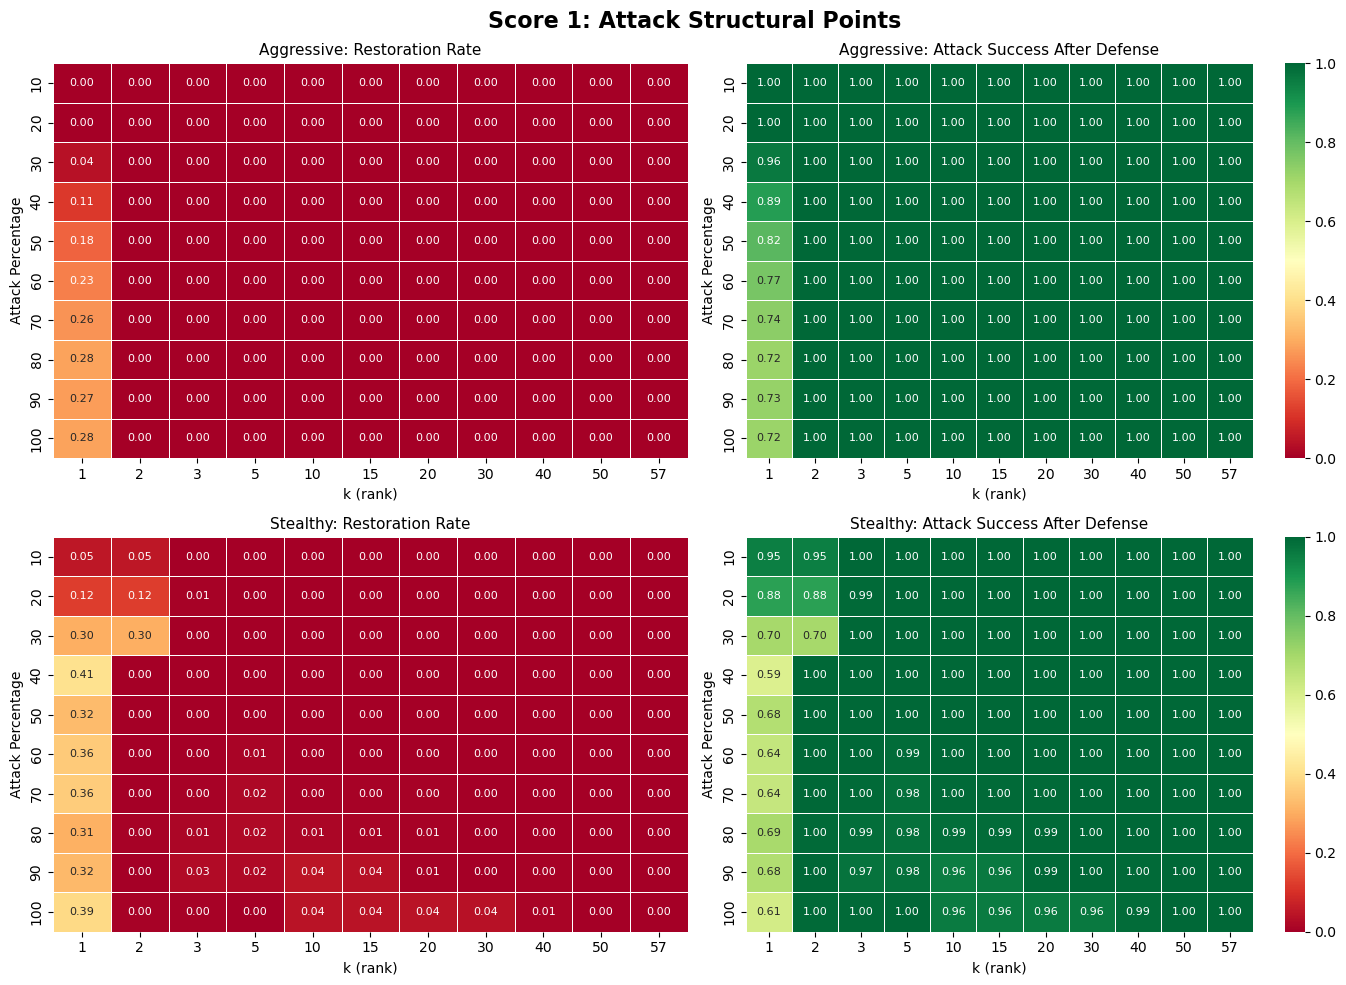

Saved vaccination_score1_noisy.png


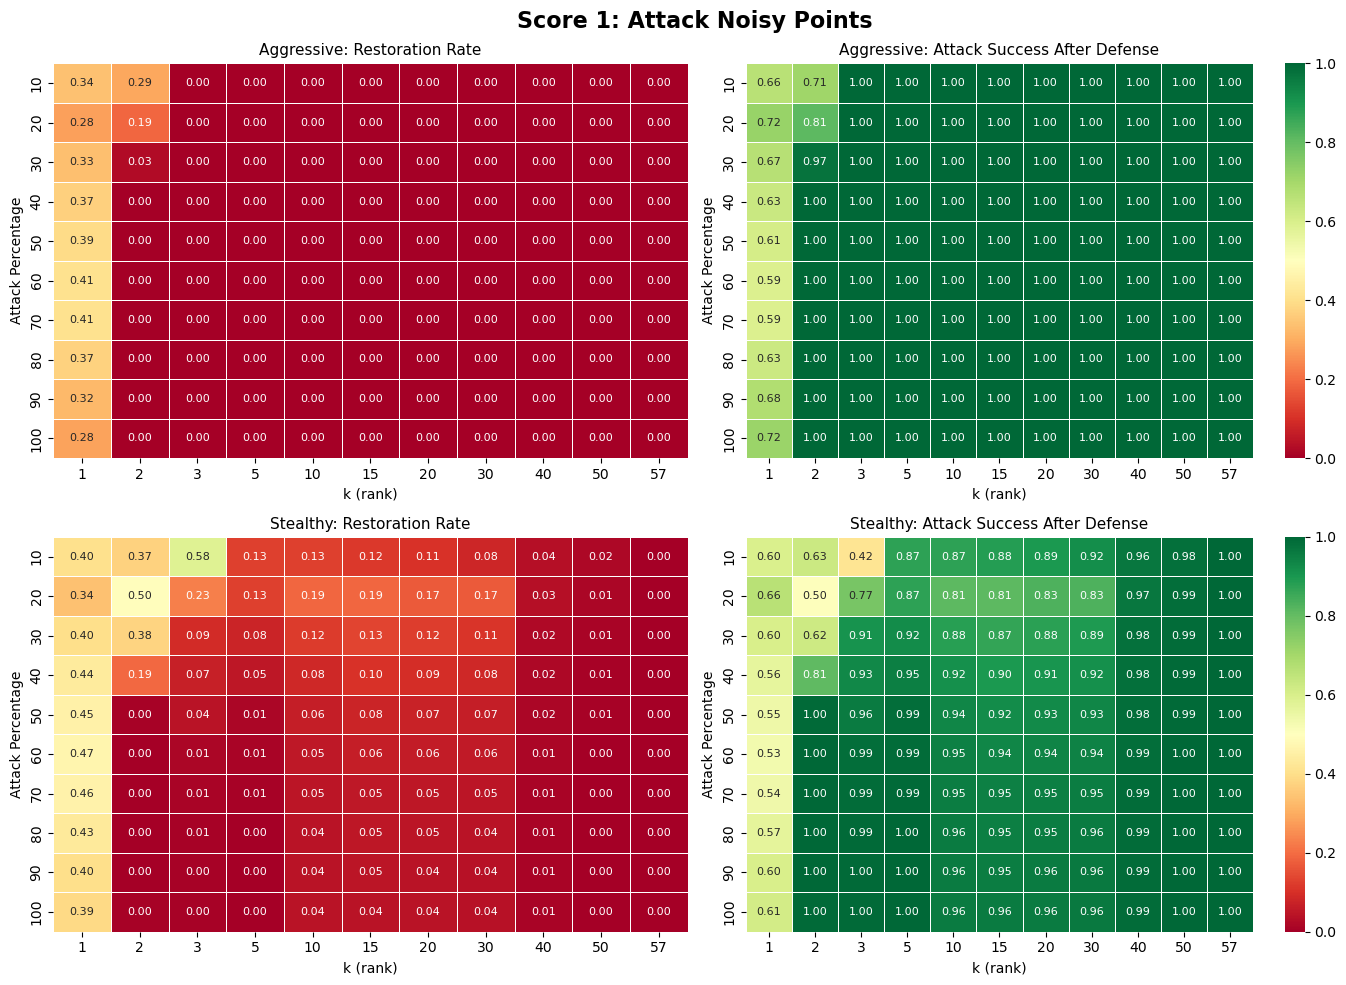

Saved vaccination_score2_structural.png


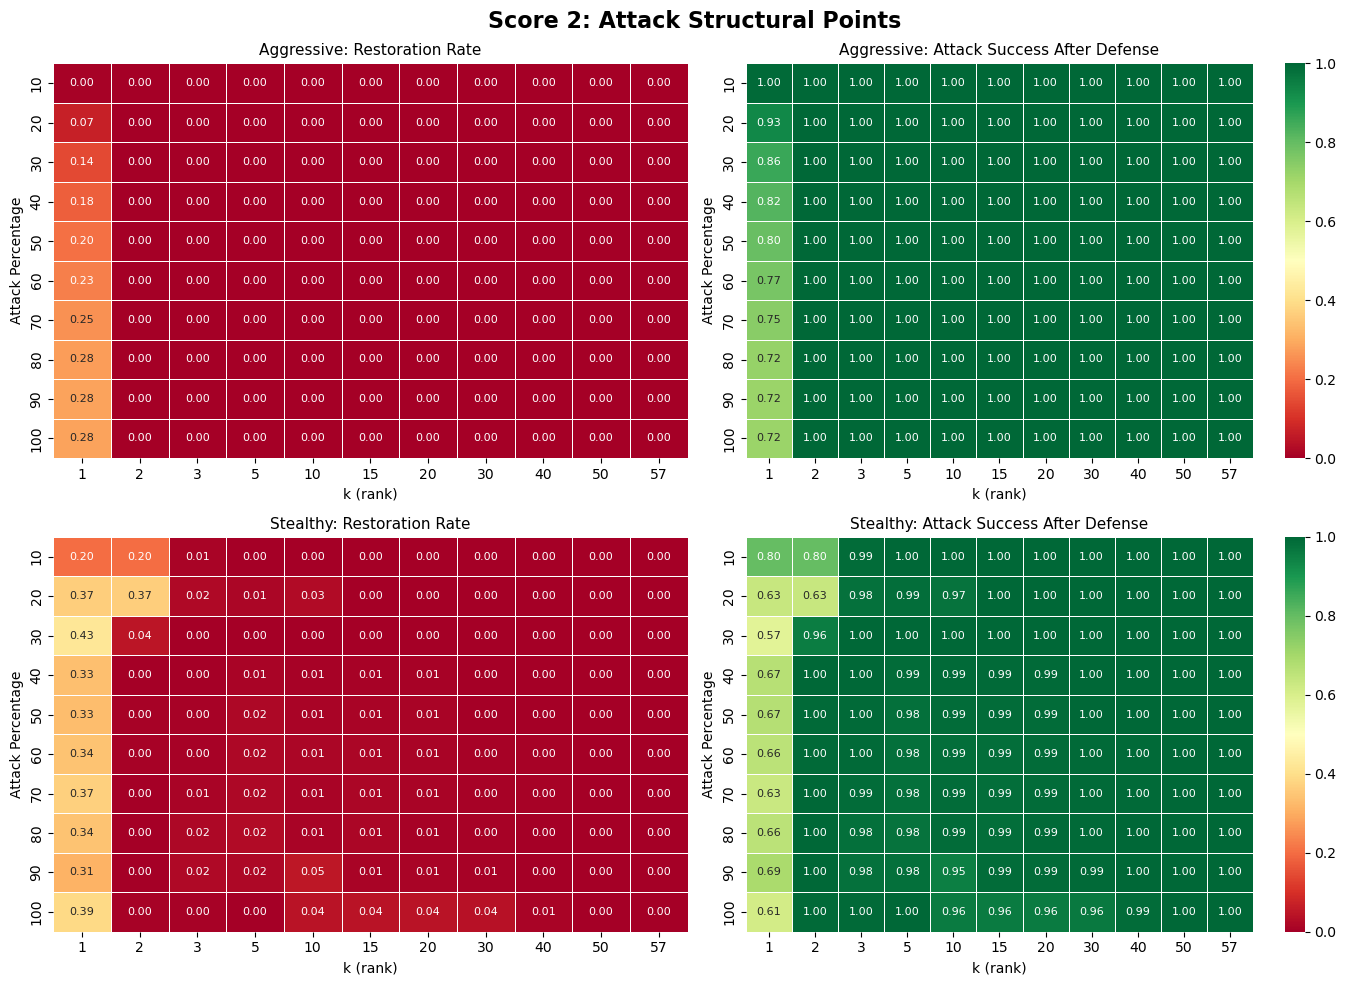

Saved vaccination_score2_noisy.png


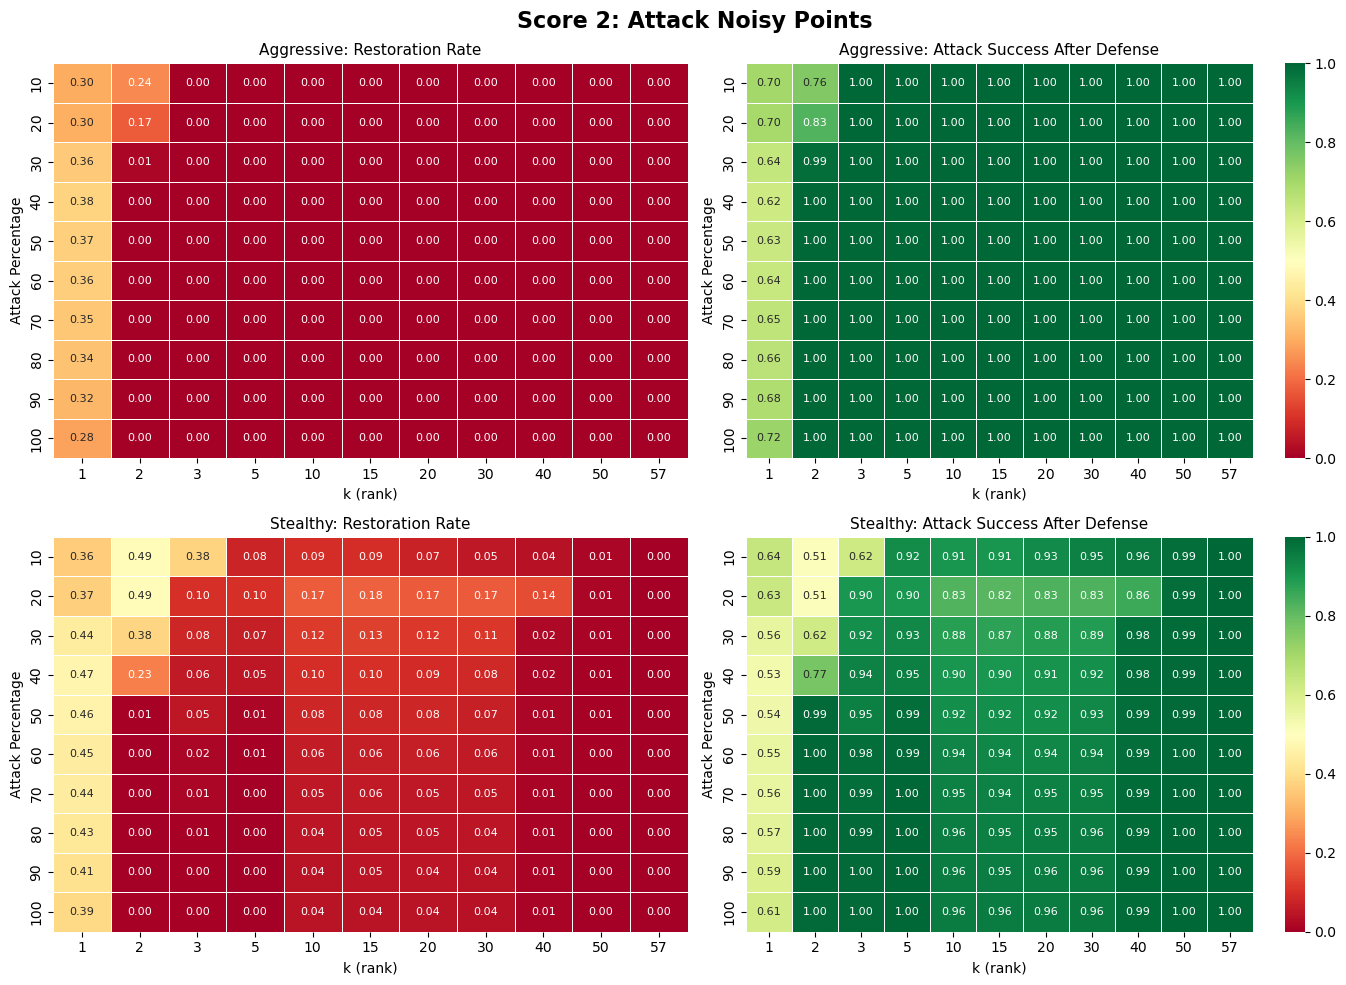

In [7]:
def plot_vaccination_heatmaps(df, score_name, tier_name, output_dir):
    """Produce a 2x2 heatmap figure matching Sowmya's format."""
    sub = df[(df['score_type'] == score_name) & (df['tier'] == tier_name)]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{score_name}: Attack {tier_name.capitalize()} Points', fontsize=16, fontweight='bold')

    panels = [
        (0, 0, 'aggressive', 'restoration_rate', 'Aggressive: Restoration Rate'),
        (0, 1, 'aggressive', 'asr_after',        'Aggressive: Attack Success After Defense'),
        (1, 0, 'stealthy',   'restoration_rate', 'Stealthy: Restoration Rate'),
        (1, 1, 'stealthy',   'asr_after',        'Stealthy: Attack Success After Defense'),
    ]

    for row, col, regime, metric, title in panels:
        ax = axes[row, col]
        regime_data = sub[sub['regime'] == regime]
        pivot = regime_data.pivot(index='attack_pct', columns='k', values=metric)
        pivot = pivot.sort_index(ascending=True)

        sns.heatmap(
            pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5,
            cbar=(col == 1),
            annot_kws={'size': 8},
        )
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('k (rank)')
        ax.set_ylabel('Attack Percentage')

    plt.tight_layout()
    fname = f'vaccination_{score_name.lower().replace(" ", "")}_{tier_name}.png'
    fig.savefig(output_dir / fname, dpi=150, bbox_inches='tight')
    print(f'Saved {fname}')
    plt.show()


for score_name in score_orders:
    for tier_name in ['structural', 'noisy']:
        plot_vaccination_heatmaps(df, score_name, tier_name, OUTPUT_DIR)

## 5. Save Summary

In [8]:
summary = {
    'config': {
        'alpha': ALPHA, 'maxiters': MAXITERS,
        'lambdas': {k: float(v) for k, v in LAMBDAS.items()},
        'attack_pcts': ATTACK_PCTS, 'k_ranks': K_RANKS,
        'n_test': int(n_test), 'n_correct': int(n_correct),
        'data_dir': str(DATA_DIR),
        'data_split': '10/40/50 (SVD/train/test); test set unchanged vs legacy 50/50',
    },
    'attack_success': {
        regime: int(attack_success[regime][correct_indices].sum())
        for regime in LAMBDAS
    },
}
with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All results saved to', OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name:45s} ({p.stat().st_size/1024:.1f} KB)')

All results saved to targeted_vaccination_results_10_40_50
  adversarial_samples.npz                       (550.0 KB)
  summary.json                                  (0.6 KB)
  vaccination_score1_noisy.png                  (284.0 KB)
  vaccination_score1_structural.png             (206.9 KB)
  vaccination_score2_noisy.png                  (280.5 KB)
  vaccination_score2_structural.png             (230.2 KB)
  vaccination_sweep.csv                         (54.2 KB)
